In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df=pd.read_csv("C:\\Users\\PRASAD YADAV\\Downloads/car data.csv")

In [16]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [17]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [19]:
df.duplicated().sum()

np.int64(2)

In [21]:
df=df.drop_duplicates()

In [22]:
df.shape

(299, 9)

In [23]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478
std,2.896868,4.984240,8.566332,39015.170352,0.248720
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [24]:
current_year = 2026

df['Car_Age'] = current_year - df['Year']

In [25]:
df[['Year', 'Car_Age', 'Selling_Price']].head()

,Year,Car_Age,Selling_Price
0,2014,12,3.35
1,2013,13,4.75
2,2017,9,7.25
3,2011,15,2.85
4,2014,12,4.60


In [26]:
df_encoded = pd.get_dummies(
    df,
    columns=['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission'],
    drop_first=True
)

df_encoded.head()

,Year,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Car_Name_Activa 3g,Car_Name_Activa 4g,Car_Name_Bajaj ct 100,Car_Name_Bajaj Avenger 150,...,Car_Name_swift,Car_Name_sx4,Car_Name_verna,Car_Name_vitara brezza,Car_Name_wagon r,Car_Name_xcent,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,12,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
1,2013,4.75,9.54,43000,0,13,False,False,False,False,...,False,True,False,False,False,False,True,False,False,True
2,2017,7.25,9.85,6900,0,9,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
3,2011,2.85,4.15,5200,0,15,False,False,False,False,...,False,False,False,False,True,False,False,True,False,True
4,2014,4.60,6.87,42450,0,12,False,False,False,False,...,True,False,False,False,False,False,True,False,False,True


In [27]:
X = df_encoded.drop('Selling_Price', axis=1)
y = df_encoded['Selling_Price']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (299, 106)
Target shape: (299,)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (239, 106)
Testing data: (60, 106)


In [29]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [30]:
y_pred = model.predict(X_test)

print("First 10 Actual Prices:")
print(y_test.head(10).values)

print("\nFirst 10 Predicted Prices:")
print(y_pred[:10])

First 10 Actual Prices:
[8.99 8.35 0.45 7.45 5.25 5.25 5.85 1.15 9.25 0.38]

First 10 Predicted Prices:
[ 9.4201  7.9705  0.4366  7.2765 16.948   5.339   6.7928  1.181   7.845
  0.2741]


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 1.3940016666666672
Mean Squared Error (MSE): 11.706140074166672
Root Mean Squared Error (RMSE): 3.4214236911213836
R² Score: 0.5458029343265128


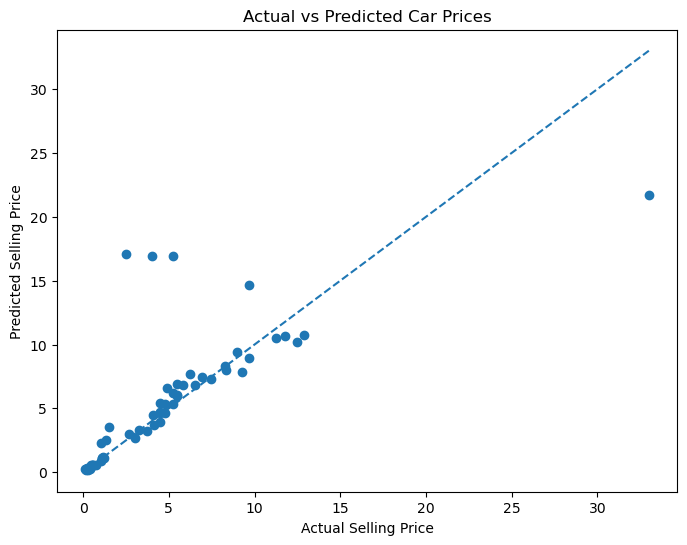

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.show()

In [33]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

Present_Price              0.883862
Year                       0.039488
Car_Age                    0.034465
Car_Name_land cruiser      0.017104
Driven_kms                 0.009380
Transmission_Manual        0.003139
Car_Name_corolla altis     0.003025
Selling_type_Individual    0.002315
Car_Name_innova            0.002105
Fuel_Type_Petrol           0.001145
dtype: float64

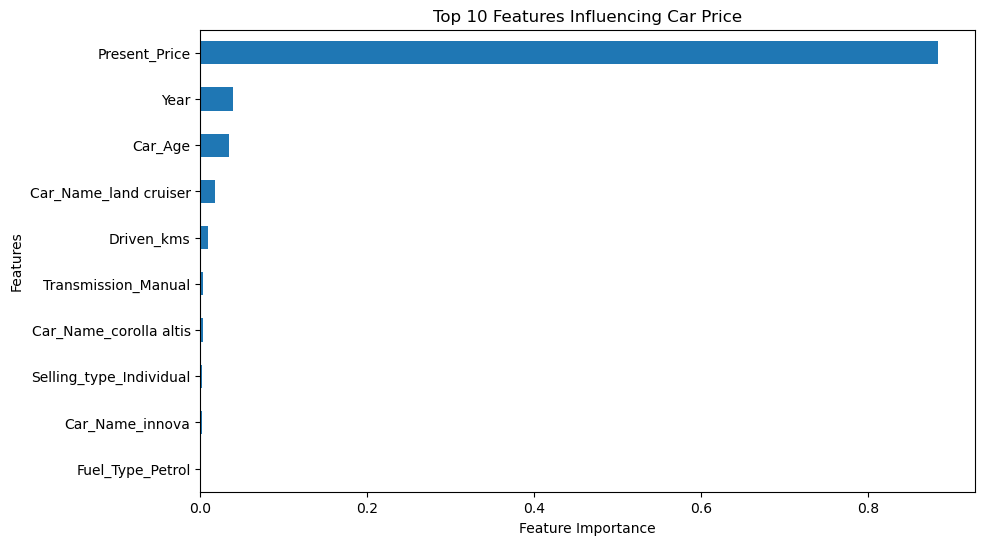

In [34]:
plt.figure(figsize=(10, 6))

feature_importance.head(10).sort_values().plot(kind='barh')

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Features Influencing Car Price")

plt.show()

In [35]:
## Conclusion

'''In this project, a machine learning model was developed to predict car selling prices using various features such as car age, present price, driven kilometers, fuel type, selling type, transmission, owner, and car name.

The dataset was cleaned by removing duplicate records, and feature engineering was performed by creating a Car Age feature. Categorical variables were converted into numerical form using one-hot encoding.

A Random Forest Regressor was trained using an 80-20 train-test split. The model achieved an R² score of approximately 0.55 on the test data, indicating that the model was able to explain a meaningful portion of the variation in car selling prices.

The actual-versus-predicted visualization and feature importance analysis helped evaluate the model and understand the factors influencing car prices.

This project demonstrates the practical application of regression, data preprocessing, feature engineering, model evaluation, and data visualization in machine learning.'''

'In this project, a machine learning model was developed to predict car selling prices using various features such as car age, present price, driven kilometers, fuel type, selling type, transmission, owner, and car name.\n\nThe dataset was cleaned by removing duplicate records, and feature engineering was performed by creating a Car Age feature. Categorical variables were converted into numerical form using one-hot encoding.\n\nA Random Forest Regressor was trained using an 80-20 train-test split. The model achieved an R² score of approximately 0.55 on the test data, indicating that the model was able to explain a meaningful portion of the variation in car selling prices.\n\nThe actual-versus-predicted visualization and feature importance analysis helped evaluate the model and understand the factors influencing car prices.\n\nThis project demonstrates the practical application of regression, data preprocessing, feature engineering, model evaluation, and data visualization in machine le